In [3]:
import numpy as np 
import scipy.signal as sp
import matplotlib.pyplot as plt 

# Génération d'un bruit coloré 
$S_{xx}(f) = 1/f^{\alpha}$

In [39]:
def colored_noise(T, fs, noise_color="white"):

    target_nt = int(T * fs)

    # Ensure nt is even
    if target_nt % 2 != 0:
        nt = target_nt + 1
    else:
        nt = target_nt

    # The number number of fft points if nt and  we have nt/2+1 points such that f>=0
    nf = nt // 2 + 1
    k = np.arange(
        1,
        nf + 1,
    ) # Frequency index starting at 1 to avoid division by zero (start point doesnt matter we could start at 10)
    if noise_color == "white":
        # psd = np.ones(f.shape)
        alpha_psd = 0
    elif noise_color == "pink":
        # psd = 1 / f
        alpha_psd = -1
    elif noise_color == "brown":
        # psd = 1 / f**2
        alpha_psd = -2
    elif noise_color == "blue":
        # psd = f
        alpha_psd = 1
    elif noise_color == "purple":
        # psd = f**2
        alpha_psd = 2
    else:
        raise ValueError("Unknown noise color")

    # Convert psd slope into amplitude spectrum slope given that Sxx(f) = |X(f)|^2
    # We wish to get Sxx(f) = f ** alpha_psd which is equivalent to |X(f)| = f ** (alpha_psd / 2)
    alpha_spec = alpha_psd / 2

    # Generate WGN spectrum
    X_f = np.random.randn(nf) + 1j * np.random.randn(nf)

    # Apply the desired correction to get the right spectrum slope
    X_f = X_f * (k**alpha_spec)

    # Apply inverse fft to get the time signal
    x_t = np.fft.irfft(X_f, n=nt)

    # Normalize to unit variance and zero mean
    x_t = (x_t - np.mean(x_t)) / np.std(x_t)

    # Remove extra point if nt was odd
    if x_t.shape[0] > target_nt:
        x_t = x_t[:-1]  # Drop last point

    # Build associated time vector
    t = np.arange(0, target_nt) / fs

    return t, x_t

In [40]:
# Example d'utilisation
fs = 1200
T = 50
colours = ["white", "pink", "brown", "blue", "purple"]
col_noise = {c:{"x": None, "sxx": None} for c in colours}
for col in colours:
    t, x = colored_noise(T, fs, noise_color=col)
    col_noise[col]["x"] = x
    f, sxx = sp.welch(x, fs, nperseg=1024, noverlap=512)
    col_noise[col]["sxx"] = sxx


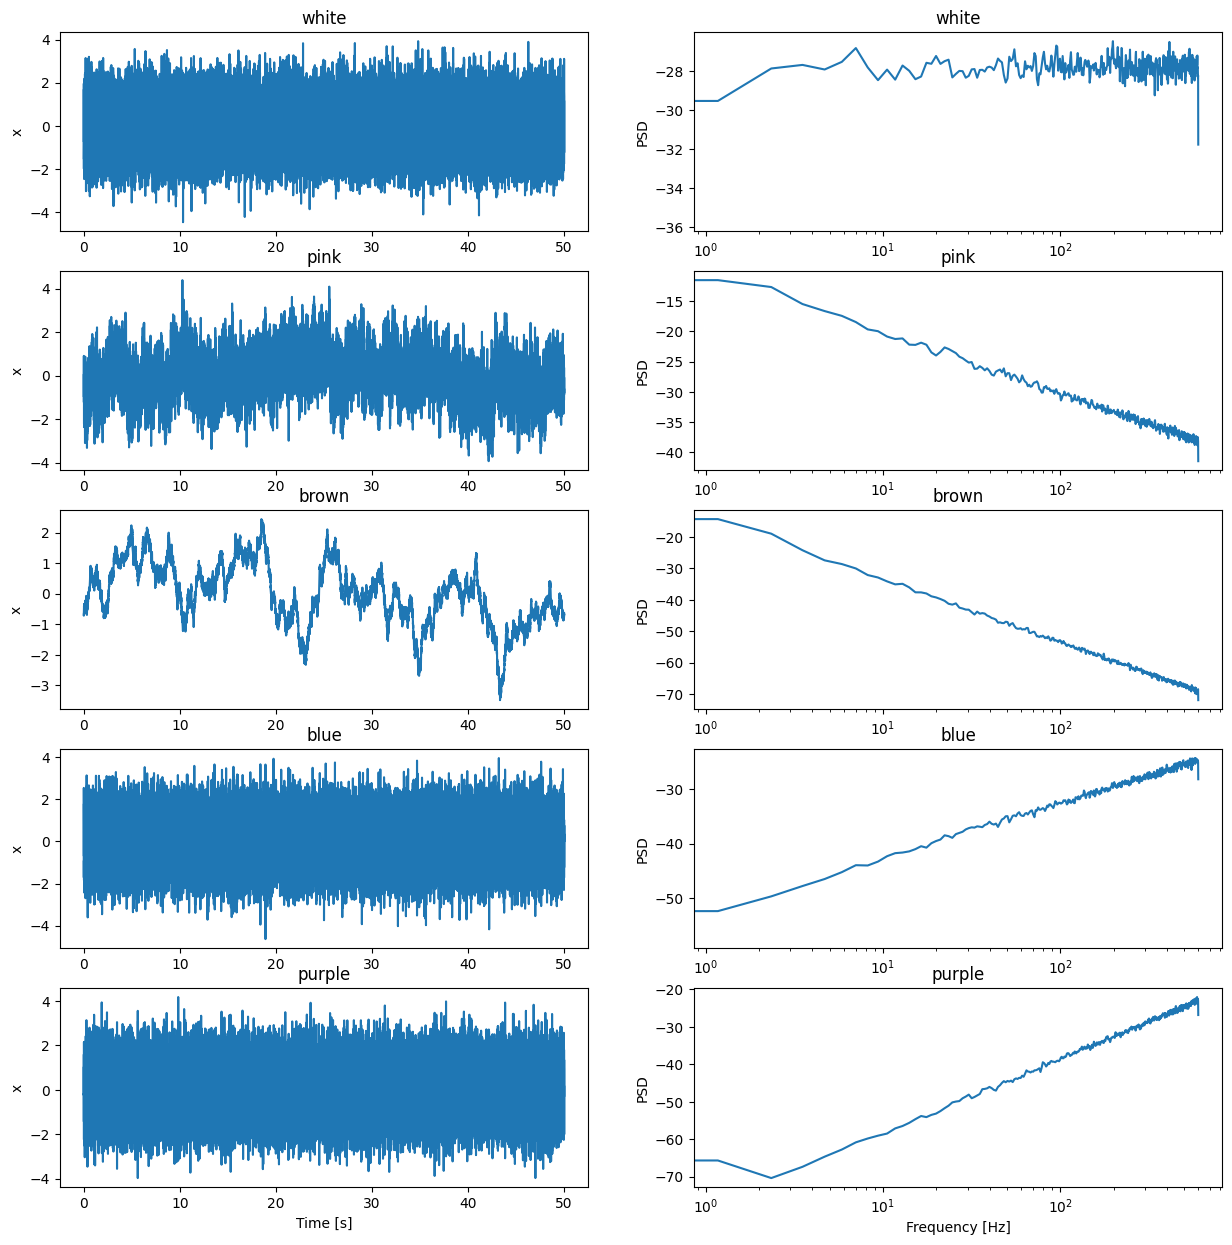

In [41]:
# Plot
fig, axs = plt.subplots(len(colours), 2, figsize=(15, 15))
axs[-1, 1].set_xlabel("Frequency [Hz]")
axs[-1, 0].set_xlabel("Time [s]")
for i, col in enumerate(colours):
    # Time
    axs[i, 0].plot(t, col_noise[col]["x"])
    axs[i, 0].set_title(col)
    axs[i, 0].set_ylabel("x")

    axs[i, 1].plot(f, 10*np.log10(col_noise[col]["sxx"]))
    axs[i, 1].set_xscale("log")
    axs[i, 1].set_title(col)
    axs[i, 1].set_ylabel("PSD")

# Génération d'un signal connaissant sa DSP 

In [28]:
def psd_to_timeserie(psd, df):
    """
    Generate a time series from a given power spectral density (PSD) using the inverse Fourier transform.
    Parameters
    ----------
    psd : np.ndarray
        Power spectral density (PSD) of the signal containing the psd components for positive frequencies (f=np.fft.rfftfreq(nt, 1/fs)).
    df : float
        Frequency resolution of the PSD.
    Returns
    -------
    t : np.ndarray
        Time vector of the signal.
    x_t : np.ndarray
        Time series generated from the PSD.
    """

    # Number of frequency components in psd
    nf = psd.shape[0]

    # Define module of the spectrum
    X_f_mod = np.sqrt(psd)  # Definition of PSD Sxx(f) = |X(f)|^2

    # Generate random phase to create the complexe spectrum
    phi_t = np.random.randn(2 * nf - 1)
    X_f_ang = np.angle(np.fft.rfft(phi_t))

    # Use random phase to create spectrum
    X_f = X_f_mod * np.exp(1j * X_f_ang)

    # Inverse fourier transform to get time signal
    x_t = np.fft.irfft(X_f)
    nt = x_t.shape[0]

    # Correct for rfft factor
    x_t *= nt * np.sqrt(df / 2)

    # Time vector
    fs = nt * df
    t = np.linspace(0, 1 / fs * (nt - 1), nt)

    return t, x_t

In [29]:
# Example 
fs = 1200
T = 500
nt = int(T * fs)

f = np.fft.rfftfreq(nt, 1 / fs)
psd = 3 * f**2 + 2 * f + 1  # Given psd law
df = fs / nt
t, x = psd_to_timeserie(psd, df)

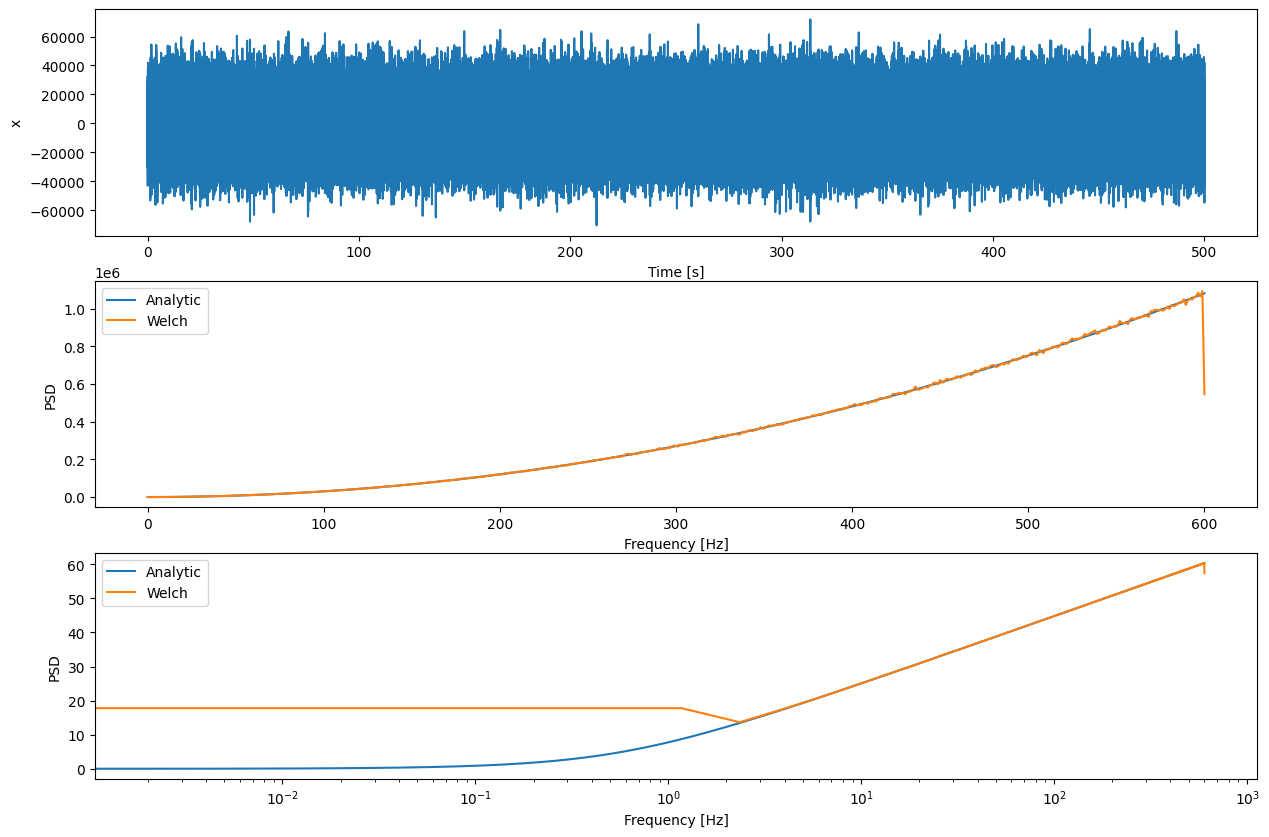

In [34]:
# Plot
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
axs[0].plot(t, x)
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("x")
ff, sxx = sp.welch(x, fs, nperseg=1024, noverlap=512)
axs[1].plot(f, psd, label="Analytic")
axs[1].plot(ff, sxx, label="Welch")
axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel("PSD")
axs[1].legend()

axs[2].plot(f, 10 * np.log10(psd), label="Analytic")
axs[2].plot(ff, 10 * np.log10(sxx), label="Welch")
axs[2].set_xscale("log")
axs[2].set_xlabel("Frequency [Hz]")
axs[2].set_ylabel("PSD")
axs[2].legend()